https://medium.com/@weidagang/demystifying-anomaly-detection-with-autoencoder-neural-networks-1e235840d879

https://www.kaggle.com/code/harshsingh2209/anomaly-detection-with-autoencoders

## Anomaly detection with autoencoders

Uses unsupervised learning (autoencoders) to identify anomalous data points. 
Implemented using keras. 

Runs the autoencoder neural net on various types of data - mnist imagery, fraud

--> eventually, add to this project classical ML methods to anomaly detection and classification.

## Imagery - anomalous image

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from sklearn.model_selection import train_test_split

2026-03-04 00:15:22.467889: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/tylerhinnendael/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/tylerhinnendael/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [27]:
# Load the MNIST dataset
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

In [28]:
ex_mnist = x_train.astype('float32') / 255.

In [39]:
ex_mnist[0].shape

(28, 28)

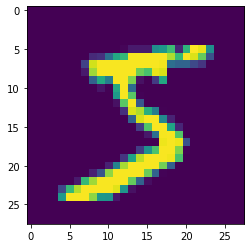

In [29]:
plt.imshow(ex_mnist[0])

In [20]:
x_train.shape

(60000, 28, 28)

In [30]:
# Normalize and reshape the data
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((-1, 28 * 28))
x_test = x_test.reshape((-1, 28 * 28))

# Create a synthetic anomalous image
anomalous_image = np.random.rand(28 * 28)

In [157]:
#anomalous_image

In [31]:
x_train.shape

(60000, 784)

In [34]:
# Build the AutoEncoder model
model = keras.Sequential([
    # Encoder: Reduce dimensionality, learn the most important features
    keras.layers.Dense(128, activation='relu', input_shape=(x_train.shape[1],)), # Reducing dimension to 128
    keras.layers.Dense(64, activation='relu'), # Further reducing dimension to 64
    keras.layers.Dense(32, activation='relu'), # Further reducing to the most compact form (bottleneck layer)

    # Decoder: Reconstruct the image from the reduced representation
    keras.layers.Dense(64, activation='relu'), # Start expanding dimension
    keras.layers.Dense(128, activation='relu'), # Continue expanding dimension
    keras.layers.Dense(x_train.shape[1], activation='sigmoid') # Restore to original image size
])

model.compile(optimizer='adam', loss='mse')

In [35]:
# Train the model
history = model.fit(x_train, x_train, epochs=20, batch_size=256, validation_data=(x_test, x_test))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0964 - val_loss: 0.0382
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0349 - val_loss: 0.0263
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0254 - val_loss: 0.0218
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0216 - val_loss: 0.0195
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0195 - val_loss: 0.0181
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0182 - val_loss: 0.0170
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0170 - val_loss: 0.0158
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0160 - val_loss: 0.0150
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0151 - val_loss: 0.0146
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0146 - val_loss: 0.0138
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0139 - val_loss: 0.0134
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

In [43]:
model

<Sequential name=sequential_1, built=True>

In [36]:
# Function to calculate reconstruction loss
def calculate_reconstruction_loss(data, model):
    reconstructions = model.predict(data)
    reconstruction_errors = np.mean(np.abs(data - reconstructions), axis=1)
    return reconstruction_errors

In [37]:
# Evaluate the model
reconstruction_loss_normal = calculate_reconstruction_loss(x_test, model)
reconstruction_loss_anomalous = calculate_reconstruction_loss(np.array([anomalous_image]), model)

# Print average reconstruction loss
print(f"Average Reconstruction Loss for Normal Data: {np.mean(reconstruction_loss_normal)}")
print(f"Reconstruction Loss for Anomalous Data: {reconstruction_loss_anomalous[0]}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Average Reconstruction Loss for Normal Data: 0.034934304654598236
Reconstruction Loss for Anomalous Data: 0.4648087775665173


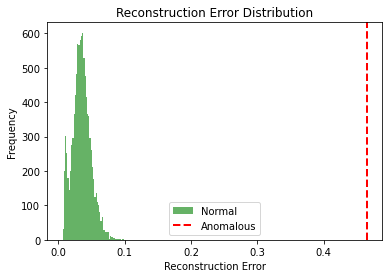

In [42]:
# Visualization of reconstruction error distribution
plt.figure(figsize=(6, 4))
plt.hist(reconstruction_loss_normal, bins=50, alpha=0.6, color='g', label='Normal')
plt.axvline(x=reconstruction_loss_anomalous[0], color='r', linestyle='dashed', linewidth=2, label='Anomalous')
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
############
########### brush up on reshaping a dataset for running through keras -> only necessary for images?
#############

## Fraud detection dataset

https://www.kaggle.com/code/harshsingh2209/anomaly-detection-with-autoencoders

### Prepare dataset

In [46]:
import pandas as pd
import os
os.chdir(os.getcwd() + '/data/')
df = pd.read_csv('card_transdata.csv')
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [49]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

cat_features = [x for x in df.columns if len(df[x].unique()) <=2] # categorical
num_features = [x for x in df.columns if x not in cat_features] # numerical - for scaling

# scale the data
col_transformer = make_column_transformer(
    (StandardScaler(), num_features)
)

df_scaled = pd.DataFrame(col_transformer.fit_transform(df), columns=num_features)
df_cat_features = df[cat_features]

df_concat = pd.concat([df_scaled, df_cat_features], axis=1)
df_concat.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,0.477882,-0.182849,0.043491,1.0,1.0,0.0,0.0,0.0
1,-0.241607,-0.188094,-0.189300,1.0,0.0,0.0,0.0,0.0
2,-0.329369,-0.163733,-0.498812,1.0,0.0,0.0,1.0,0.0
3,-0.372854,0.021806,-0.522048,1.0,1.0,0.0,1.0,0.0
4,0.268572,-0.172968,0.142373,1.0,1.0,0.0,1.0,0.0


In [50]:
## drop the fraud column for training data

x = df_concat.drop(['fraud'], axis=1)
y = df_concat['fraud']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=40)

y_train = y_train.astype(bool)
y_test = y_test.astype(bool)

X_train_genuine = X_train[~y_train]
X_test_genuine = X_test[~y_test]

X_train_fraud = X_train[y_train]
X_test_fraud = X_test[y_test]

In [51]:
X_train_genuine.shape

(730059, 7)

In [65]:
X_train.shape

(800000, 7)

In [68]:
X_test_genuine.shape

(182538, 7)

In [66]:
X_test.shape

(200000, 7)

In [105]:
y_test

884729    False
712573    False
228524     True
322732    False
937308    False
          ...  
404893    False
826194     True
515705    False
341928    False
483739    False
Name: fraud, Length: 200000, dtype: bool

### 1st hyperparam combination

Resulted in poor recall score. 

loss = 'mse'
activation = 'sigmoid'

#### Build fraud model and fit to training data


In [67]:
# Build the AutoEncoder model
fraud_model = keras.Sequential([
    # Encoder: Reduce dimensionality, learn the most important features
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Reducing dimension to 64
    keras.layers.Dense(16, activation='relu'), # Further reducing dimension to 16

    # Decoder: Reconstruct the image from the reduced representation
    keras.layers.Dense(16, activation='relu'), # Start expanding dimension
    keras.layers.Dense(64, activation='relu'), # Continue expanding dimension
    keras.layers.Dense(X_train.shape[1], activation='sigmoid') # Restore to original array size
])

fraud_model.compile(optimizer='adam', loss='mse') 

/Users/tylerhinnendael/opt/anaconda3/lib/python3.9/site-packages/keras/src/layers/core/dense.py:86: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
# Train the model
history = fraud_model.fit(X_train_genuine, X_train_genuine, epochs=20, batch_size=64, validation_data=(X_test, X_test))

Epoch 1/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 12s 944us/step - loss: 0.2651 - val_loss: 0.2668
Epoch 2/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 936us/step - loss: 0.1883 - val_loss: 0.2665
Epoch 3/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 943us/step - loss: 0.1928 - val_loss: 0.2667
Epoch 4/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 953us/step - loss: 0.1836 - val_loss: 0.2665
Epoch 5/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 951us/step - loss: 0.2119 - val_loss: 0.2665
Epoch 6/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 949us/step - loss: 0.2126 - val_loss: 0.2668
Epoch 7/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 970us/step - loss: 0.2151 - val_loss: 0.2665
Epoch 8/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 953us/step - loss: 0.2142 - val_loss: 0.2664
Epoch 9/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 956us/step - loss: 0.2122 - val_loss: 0.2665
Epoch 10/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 1000us/step - loss: 0.1898 - val_loss: 0.2664
Epoch 11/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 980us/step - loss: 

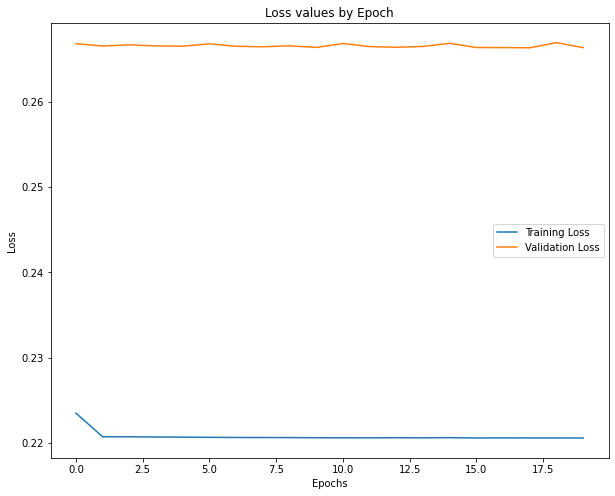

In [73]:
plt.figure(figsize=(10,8))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss values by Epoch")
plt.show()

#### eval - 1st method

In [78]:
# Evaluate the model - first method
reconstruction_loss_normal_fraud = calculate_reconstruction_loss(X_test_genuine, fraud_model)
reconstruction_loss_anomalous_fraud = calculate_reconstruction_loss(X_test_fraud, fraud_model)

# Print average reconstruction loss
print(f"Average Reconstruction Loss for Normal Data: {np.mean(reconstruction_loss_normal_fraud)}")
print(f"Average Reconstruction Loss for Anomalous Data: {np.mean(reconstruction_loss_anomalous_fraud)}")


5705/5705 ━━━━━━━━━━━━━━━━━━━━ 3s 568us/step
546/546 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step
Average Reconstruction Loss for Normal Data: 0.10962595981627975
Reconstruction Loss for Anomalous Data: 0.27959658760415057


In [91]:
reconstruction_loss_normal_fraud.describe()

count    182538.000000
mean          0.109626
std           0.137287
min           0.000228
25%           0.068423
50%           0.097385
75%           0.128212
max          16.172687
dtype: float64

In [92]:
reconstruction_loss_anomalous_fraud.describe()

count    17462.000000
mean         0.279597
std          0.388239
min          0.000434
25%          0.085110
50%          0.166894
75%          0.326959
max          7.921577
dtype: float64

In [77]:
reconstruction_loss_anomalous_fraud

228524    0.143744
740732    0.393238
469723    0.089374
826115    0.902048
379624    0.400726
            ...   
11428     0.173416
782291    0.336719
279564    0.480451
965503    0.320506
826194    0.013208
Length: 17462, dtype: float64

In [96]:
max_val = 4
print(reconstruction_loss_normal_fraud[reconstruction_loss_normal_fraud < max_val].shape)
print(reconstruction_loss_anomalous_fraud[reconstruction_loss_anomalous_fraud < max_val].shape)

(182520,)
(17437,)


In [86]:
list(reconstruction_loss_anomalous_fraud)[0]

0.14374400175556978

**Error Distribution**

We can see below that the distributions for normal and fraud classes have quite a bit of overlap, which tells me without even looking at the evaluation metrics such as recall that this model is probably not best for detecting all true positives, and needs further training/hyperparam tuning.

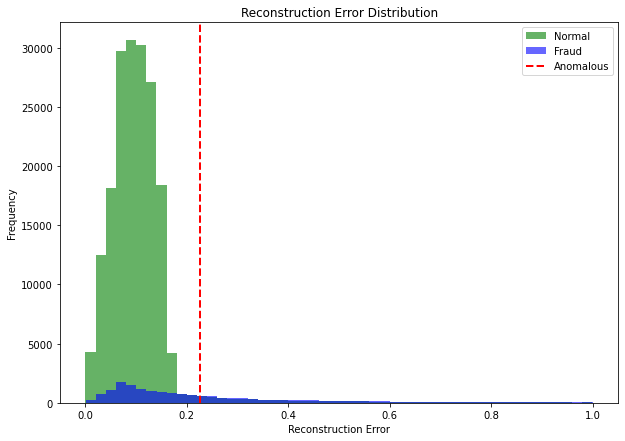

In [99]:
max_val = 1


plt.figure(figsize=(10,7 ))
plt.hist(reconstruction_loss_normal_fraud[reconstruction_loss_normal_fraud < max_val],
         bins=50, alpha=0.6, color='g', label='Normal')
plt.hist(reconstruction_loss_anomalous_fraud[reconstruction_loss_anomalous_fraud < max_val],
         bins=50, alpha=0.6, color='b', label='Fraud')
plt.axvline(x=np.mean(reconstruction_loss_anomalous_fraud[reconstruction_loss_anomalous_fraud < max_val]), 
            color='r', linestyle='dashed', linewidth=2, label='Anomalous')
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.legend()
plt.show()

#### Evaluation - 2nd method

In [101]:
from tensorflow.keras.losses import mae
from tensorflow.keras.metrics import Mean

In [102]:
####
reconstructions = fraud_model.predict(X_test, verbose = 0)
reconstruction_error = mae(reconstructions, X_test)

In [103]:
reconstruction_error

<tf.Tensor: shape=(200000,), dtype=float64, numpy=
array([0.11528558, 0.0265585 , 0.143744  , ..., 0.13364436, 0.14189694,
       0.14488034])>

In [104]:
reconstructions_df = pd.DataFrame({'error': reconstruction_error, 'y_true': y_test}).reset_index(drop = True)
reconstructions_df.head()

,error,y_true
0,0.115286,False
1,0.026558,False
2,0.143744,True
3,0.081977,False
4,0.148375,False


##### Find optimal threshold

In [112]:
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

def thresholdTuning(df, iterations):
    
    thresh_df = {
        'threshold': [],
        'accuracy': [],
        'precision': [],
        'recall': []
    }
    
    for i in range(iterations):
        thresh_value = df['error'].quantile(i/iterations)
        preds = df['error'] > thresh_value
        cr = classification_report(df['y_true'], preds, output_dict=True)
        acc = cr['accuracy']
        prec = cr['macro avg']['precision']
        rc = cr['macro avg']['recall']
        
        thresh_df['threshold'].append(thresh_value)
        thresh_df['accuracy'].append(acc)
        thresh_df['precision'].append(prec)
        thresh_df['recall'].append(rc)
        
        print(f"Threshold: {thresh_value:.4f}\tAccuracy: {acc:.3f}\t\tPrecision: {prec:.3f}\tRecall Score: {rc:.3f}")
        
    return pd.DataFrame(thresh_df)
        
thresh_df = thresholdTuning(reconstructions_df, 20)

Threshold: 0.0002	Accuracy: 0.087		Precision: 0.544	Recall Score: 0.500
Threshold: 0.0288	Accuracy: 0.132		Precision: 0.518	Recall Score: 0.511
Threshold: 0.0436	Accuracy: 0.176		Precision: 0.517	Recall Score: 0.519
Threshold: 0.0544	Accuracy: 0.220		Precision: 0.517	Recall Score: 0.528
Threshold: 0.0625	Accuracy: 0.265		Precision: 0.519	Recall Score: 0.538
Threshold: 0.0695	Accuracy: 0.309		Precision: 0.520	Recall Score: 0.547
Threshold: 0.0755	Accuracy: 0.353		Precision: 0.522	Recall Score: 0.558
Threshold: 0.0809	Accuracy: 0.398		Precision: 0.524	Recall Score: 0.567
Threshold: 0.0863	Accuracy: 0.443		Precision: 0.526	Recall Score: 0.579
Threshold: 0.0931	Accuracy: 0.488		Precision: 0.529	Recall Score: 0.591
Threshold: 0.0997	Accuracy: 0.534		Precision: 0.534	Recall Score: 0.606
Threshold: 0.1060	Accuracy: 0.580		Precision: 0.539	Recall Score: 0.621
Threshold: 0.1122	Accuracy: 0.626		Precision: 0.546	Recall Score: 0.637
Threshold: 0.1187	Accuracy: 0.673		Precision: 0.554	Recall Score

In [114]:
threshold = thresh_df[thresh_df['recall'] == thresh_df['recall'].max()]['threshold'].values[0]
print(f"Threshold with Maximum Recall: {threshold:.6f}")

Threshold with Maximum Recall: 0.161043


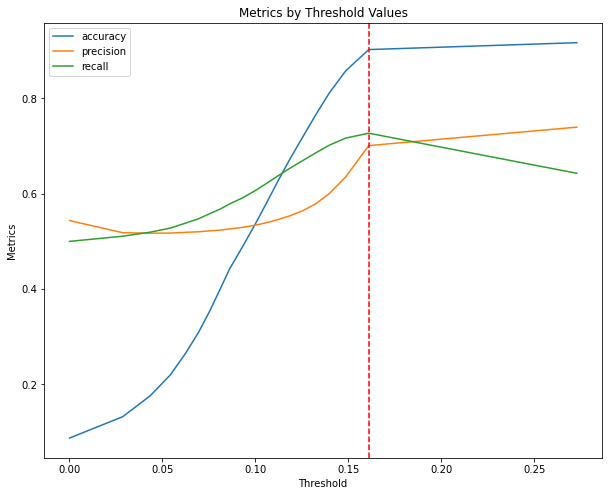

In [117]:
plt.figure(figsize=(10,8))
plt.plot(np.array(thresh_df['threshold']), np.array(thresh_df['accuracy']), label='accuracy')
plt.plot(np.array(thresh_df['threshold']), np.array(thresh_df['precision']), label='precision')
plt.plot(np.array(thresh_df['threshold']), np.array(thresh_df['recall']), label='recall')
plt.axvline(x=threshold, color='r', linestyle='dashed')
plt.xlabel('Threshold')
plt.ylabel('Metrics')
plt.title('Metrics by Threshold Values')
plt.legend()
plt.show()

##### Examine classified results and evaluate model metrics

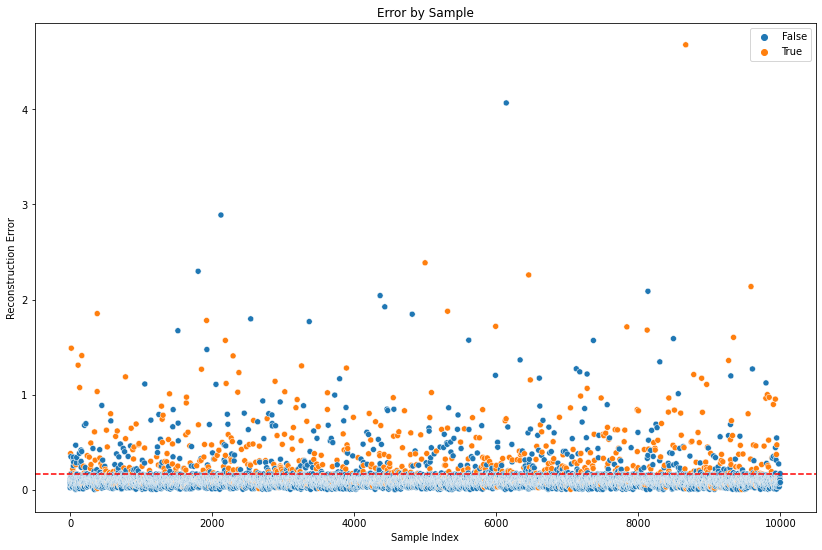

In [121]:
import seaborn as sns

temp = reconstructions_df.sample(frac=0.05, random_state=42).reset_index(drop=True)
plt.figure(figsize=(14,9))
sns.scatterplot(data=temp, x=temp.index, y='error', hue='y_true')
plt.axhline(y=threshold, color='r', linestyle='dashed')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Error by Sample')
plt.legend()
plt.show()

In [122]:
reconstructions_df['y_pred'] = reconstructions_df['error'] > threshold
reconstructions_df.head()

,error,y_true,y_pred
0,0.115286,False,False
1,0.026558,False,False
2,0.143744,True,False
3,0.081977,False,False
4,0.148375,False,False


In [126]:
print(classification_report(reconstructions_df['y_true'], reconstructions_df['y_pred']))

              precision    recall  f1-score   support

       False       0.95      0.94      0.95    182538
        True       0.45      0.51      0.48     17462

    accuracy                           0.90    200000
   macro avg       0.70      0.73      0.71    200000
weighted avg       0.91      0.90      0.91    200000



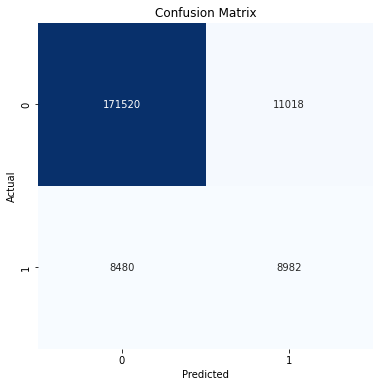

In [127]:
cm = confusion_matrix(reconstructions_df['y_true'],reconstructions_df['y_pred'])
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, cmap='Blues', cbar=False, fmt='.6g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [128]:

print(f"Recall Score: {recall_score(reconstructions_df['y_true'],reconstructions_df['y_pred'])*100:.3f}%")
print(f"Accuracy Score: {accuracy_score(reconstructions_df['y_true'],reconstructions_df['y_pred'])*100:.3f}%")

Recall Score: 51.437%
Accuracy Score: 90.251%


**Conclusion**

There will be some trade-off with accuracy when we choose to maximize recall. In this case, our recall score (ability to catch true positives) is far too low. Let's try a different activation function and loss calculation, below.

### Attempt 2 (without grid search)

loss = 'mae'
activation = 'relu'

In [138]:
# Build the AutoEncoder model
fraud_model = keras.Sequential([
    # Encoder: Reduce dimensionality, learn the most important features
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Reducing dimension to 64
    keras.layers.Dense(16, activation='relu'), # Further reducing dimension to 16

    # Decoder: Reconstruct the image from the reduced representation
    keras.layers.Dense(16, activation='relu'), # Start expanding dimension
    keras.layers.Dense(64, activation='relu'), # Continue expanding dimension
    keras.layers.Dense(X_train.shape[1], activation='relu') # Restore to original array size
])

fraud_model.compile(optimizer='adam', loss='mae');

In [139]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

earlystopping = EarlyStopping(monitor='val_loss',
                              min_delta = 0, 
                              patience = 2, 
                              verbose = 1,
                              restore_best_weights=True)

callbacks = [earlystopping]

In [140]:
# Train the model
history_params2 = fraud_model.fit(X_train_genuine, X_train_genuine, 
                                  epochs=20, batch_size=64, 
                                  validation_data=(X_test, X_test),
                                 callbacks = callbacks)

Epoch 1/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 12s 948us/step - loss: 0.1266 - val_loss: 0.1281
Epoch 2/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 925us/step - loss: 0.1133 - val_loss: 0.1273
Epoch 3/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 10s 903us/step - loss: 0.1126 - val_loss: 0.1271
Epoch 4/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 953us/step - loss: 0.1123 - val_loss: 0.1267
Epoch 5/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 952us/step - loss: 0.1123 - val_loss: 0.1265
Epoch 6/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 945us/step - loss: 0.1119 - val_loss: 0.1262
Epoch 7/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 935us/step - loss: 0.1119 - val_loss: 0.1260
Epoch 8/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 934us/step - loss: 0.1118 - val_loss: 0.1266
Epoch 9/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 932us/step - loss: 0.1118 - val_loss: 0.1260
Epoch 10/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 927us/step - loss: 0.1117 - val_loss: 0.1262
Epoch 11/20
11408/11408 ━━━━━━━━━━━━━━━━━━━━ 11s 949us/step - loss: 0

#### Examine loss through each epoch

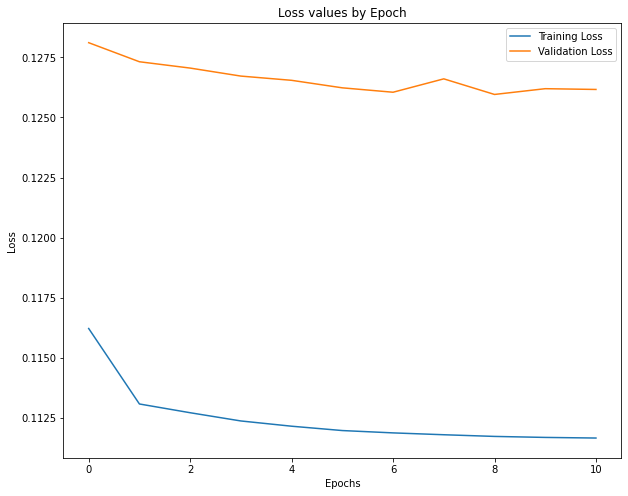

In [141]:
plt.figure(figsize=(10,8))
plt.plot(history_params2.history['loss'], label="Training Loss")
plt.plot(history_params2.history['val_loss'], label="Validation Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss values by Epoch")
plt.show()

#### Reconstruction process

Get reconstruction errors
Assign to the dataframe for each observation

In [142]:
fraud_model

<Sequential name=sequential_9, built=True>

##### 1st method

In [143]:
# Evaluate the model - first method
reconstruction_loss_normal_fraud = calculate_reconstruction_loss(X_test_genuine, fraud_model)
reconstruction_loss_anomalous_fraud = calculate_reconstruction_loss(X_test_fraud, fraud_model)

# Print average reconstruction loss
print(f"Average Reconstruction Loss for Normal Data: {np.mean(reconstruction_loss_normal_fraud)}")
print(f"Average Reconstruction Loss for Anomalous Data: {np.mean(reconstruction_loss_anomalous_fraud)}")


5705/5705 ━━━━━━━━━━━━━━━━━━━━ 3s 602us/step
546/546 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step
Average Reconstruction Loss for Normal Data: 0.11136409913307183
Average Reconstruction Loss for Anomalous Data: 0.2785018885160995


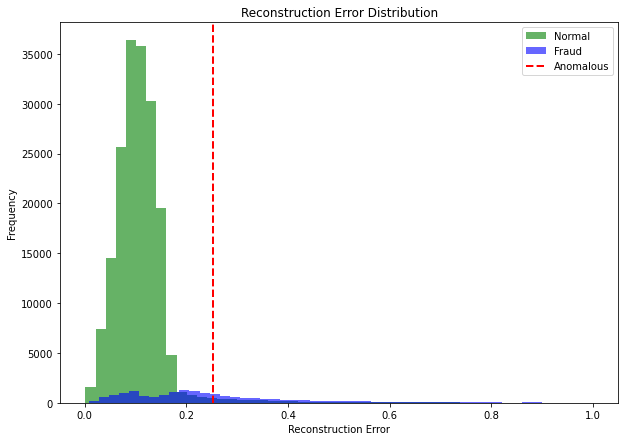

In [144]:
max_val = 1

plt.figure(figsize=(10,7 ))
plt.hist(reconstruction_loss_normal_fraud[reconstruction_loss_normal_fraud < max_val],
         bins=50, alpha=0.6, color='g', label='Normal')
plt.hist(reconstruction_loss_anomalous_fraud[reconstruction_loss_anomalous_fraud < max_val],
         bins=50, alpha=0.6, color='b', label='Fraud')
plt.axvline(x=np.mean(reconstruction_loss_anomalous_fraud[reconstruction_loss_anomalous_fraud < max_val]), 
            color='r', linestyle='dashed', linewidth=2, label='Anomalous')
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.legend()
plt.show()

##### 2nd method

In [145]:
####
reconstructions = fraud_model.predict(X_test, verbose = 0)
reconstruction_error = mae(reconstructions, X_test)

In [146]:
reconstructions_df = pd.DataFrame({'error': reconstruction_error, 'y_true': y_test}).reset_index(drop = True)
reconstructions_df.head()

,error,y_true
0,0.115468,False
1,0.060470,False
2,0.279575,True
3,0.083026,False
4,0.148621,False


##### find optimal threshold for reconstruction

In [147]:
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

def thresholdTuning(df, iterations):
    
    thresh_df = {
        'threshold': [],
        'accuracy': [],
        'precision': [],
        'recall': []
    }
    
    for i in range(iterations):
        thresh_value = df['error'].quantile(i/iterations)
        preds = df['error'] > thresh_value
        cr = classification_report(df['y_true'], preds, output_dict=True)
        acc = cr['accuracy']
        prec = cr['macro avg']['precision']
        rc = cr['macro avg']['recall']
        
        thresh_df['threshold'].append(thresh_value)
        thresh_df['accuracy'].append(acc)
        thresh_df['precision'].append(prec)
        thresh_df['recall'].append(rc)
        
        print(f"Threshold: {thresh_value:.4f}\tAccuracy: {acc:.3f}\t\tPrecision: {prec:.3f}\tRecall Score: {rc:.3f}")
        
    return pd.DataFrame(thresh_df)
        
thresh_df = thresholdTuning(reconstructions_df, 20)

Threshold: 0.0016	Accuracy: 0.087		Precision: 0.544	Recall Score: 0.500
Threshold: 0.0424	Accuracy: 0.132		Precision: 0.516	Recall Score: 0.510
Threshold: 0.0565	Accuracy: 0.177		Precision: 0.520	Recall Score: 0.522
Threshold: 0.0661	Accuracy: 0.223		Precision: 0.524	Recall Score: 0.538
Threshold: 0.0741	Accuracy: 0.270		Precision: 0.527	Recall Score: 0.554
Threshold: 0.0806	Accuracy: 0.316		Precision: 0.530	Recall Score: 0.571
Threshold: 0.0861	Accuracy: 0.363		Precision: 0.534	Recall Score: 0.589
Threshold: 0.0914	Accuracy: 0.410		Precision: 0.537	Recall Score: 0.606
Threshold: 0.0966	Accuracy: 0.457		Precision: 0.541	Recall Score: 0.623
Threshold: 0.1019	Accuracy: 0.504		Precision: 0.546	Recall Score: 0.642
Threshold: 0.1071	Accuracy: 0.551		Precision: 0.551	Recall Score: 0.660
Threshold: 0.1123	Accuracy: 0.598		Precision: 0.558	Recall Score: 0.679
Threshold: 0.1179	Accuracy: 0.647		Precision: 0.567	Recall Score: 0.701
Threshold: 0.1240	Accuracy: 0.695		Precision: 0.578	Recall Score

In [149]:
threshold = thresh_df[thresh_df['recall'] == thresh_df['recall'].max()]['threshold'].values[0]
print(f"Threshold with Maximum Recall: {threshold:.6f}")

Threshold with Maximum Recall: 0.168871


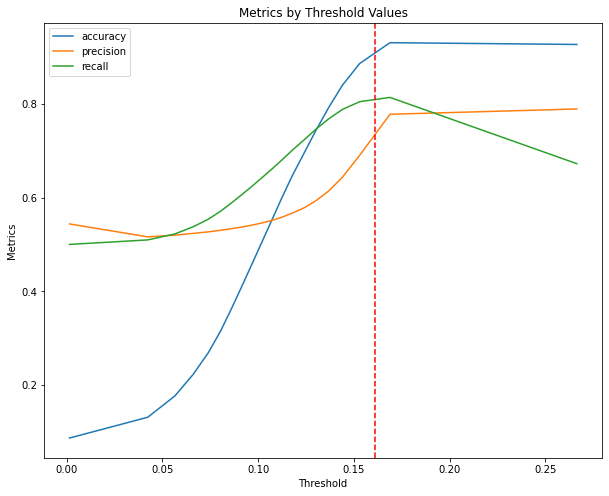

In [148]:
plt.figure(figsize=(10,8))
plt.plot(np.array(thresh_df['threshold']), np.array(thresh_df['accuracy']), label='accuracy')
plt.plot(np.array(thresh_df['threshold']), np.array(thresh_df['precision']), label='precision')
plt.plot(np.array(thresh_df['threshold']), np.array(thresh_df['recall']), label='recall')
plt.axvline(x=threshold, color='r', linestyle='dashed')
plt.xlabel('Threshold')
plt.ylabel('Metrics')
plt.title('Metrics by Threshold Values')
plt.legend()
plt.show()

#### Examine classification results for anomalous datapoints -> compute metrics

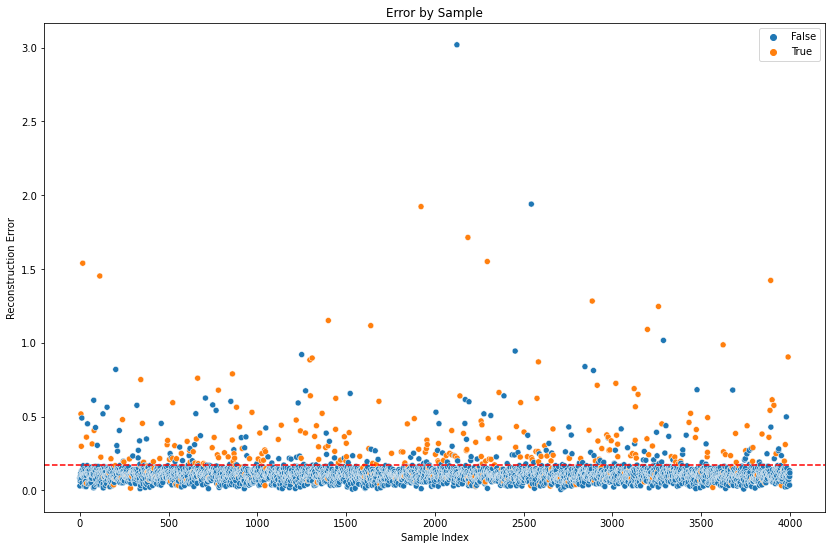

In [152]:
import seaborn as sns

temp = reconstructions_df.sample(frac=0.02, random_state=42).reset_index(drop=True) ## only visualizing 2% of the data
plt.figure(figsize=(14,9))
sns.scatterplot(data=temp, x=temp.index, y='error', hue='y_true')
plt.axhline(y=threshold, color='r', linestyle='dashed')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Error by Sample')
plt.legend()
plt.show()

In [153]:
reconstructions_df['y_pred'] = reconstructions_df['error'] > threshold
reconstructions_df.head()

,error,y_true,y_pred
0,0.115468,False,False
1,0.060470,False,False
2,0.279575,True,True
3,0.083026,False,False
4,0.148621,False,False


In [154]:
print(classification_report(reconstructions_df['y_true'], reconstructions_df['y_pred']))

              precision    recall  f1-score   support

       False       0.97      0.95      0.96    182538
        True       0.59      0.67      0.63     17462

    accuracy                           0.93    200000
   macro avg       0.78      0.81      0.79    200000
weighted avg       0.93      0.93      0.93    200000



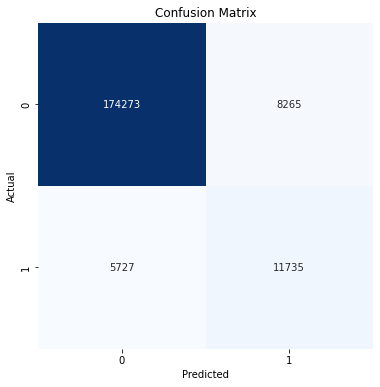

In [155]:
cm = confusion_matrix(reconstructions_df['y_true'],reconstructions_df['y_pred'])
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, cmap='Blues', cbar=False, fmt='.6g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [156]:
print(f"Recall Score: {recall_score(reconstructions_df['y_true'],reconstructions_df['y_pred'])*100:.3f}%")
print(f"Accuracy Score: {accuracy_score(reconstructions_df['y_true'],reconstructions_df['y_pred'])*100:.3f}%")

Recall Score: 67.203%
Accuracy Score: 93.004%


**CONCLUSION**

For the fraud dataset, our model improved when adding in a different loss calculation, activation function, and early stopping to prevent overfitting. 
Our recall score improved modestly (by 15%), but it is still far too low to deploy the model. We want to increase the number of true positives caught in anomaly detection use cases, so we still need to significantly increase the recall score. The recall threshold will depend on many factors, such as the risk calculation of the customer, resources available for further screening, and the cost to missing true positives. 

Next steps should be hyperparameter optimization (grid search), and evaluating varying architectures of the neural net, such as the number of layers. 

## Run on a cyber security dataset

## Graph Neural net

https://developer.nvidia.com/blog/applying-autoencoder-based-gnns-for-high-throughput-network-anomaly-detection-in-netflow-data/